In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
c_l = 1
class DustyFLD:
    """FLD for dust+gas temperatures coupled by radiation and collisions"""

    def __init__(self, cd, kd, gamma, cg=1, kg=1, a_rad=1, fd=None, fg=0, fE=0):
        self.cd = cd 
        self.cg = cg

        self.kd = kd 
        self.kg = kg 

        self.fg = fg
        self.fE = fE
        if fd is None: 
            self.fd = np.zeros_like(self.cd)
        else:
            self.fd = fd

        self.gamma = gamma 

        self.a_rad = a_rad

    def ode(self, Tg, Td, Erad):
        dTg_dt = (self.fg  + np.sum(self.gamma*(Td-Tg)) + self.kg*c_l*(Erad - self.a_rad*Tg**4)) / self.cg
        dTd_dt = (self.fd  -        self.gamma*(Td-Tg)  + self.kd*c_l*(Erad - self.a_rad*Td**4)) / self.cd 
        dEr_dt =  self.fE  - self.kg*c_l*(Erad - self.a_rad*Tg**4) - np.sum(self.kd*c_l*(Erad - self.a_rad*Td**4))

        return [dTg_dt, dTd_dt, dEr_dt]

    def implicit_step(self, dt, Tg, Td, Erad):
        lg = 4*self.a_rad*self.kg*c_l*Tg**3
        ld = 4*self.a_rad*self.kd*c_l*Td**3

        fg = (self.fg + 0.75*lg*Tg)
        fd = (self.fd + 0.75*ld*Td)
        fE =  self.fE - 0.75*lg*Tg - np.sum(0.75*ld*Td)      
        
        Zd = (self.cd + ld*dt + self.gamma*dt)
        Zg = (self.cg + lg*dt + np.sum(self.gamma*dt*(self.cd + ld*dt)/Zd))

        u_tot = self.cg*Tg + fg*dt + np.sum(self.gamma*dt*(self.cd*Td + fd*dt)/Zd)
        c_tot = self.cg + np.sum(self.gamma*dt*self.cd/Zd)
        k_tot = self.kg + np.sum(self.gamma*dt*self.kd/Zd)

        RHS = Erad + fE*dt + np.sum(ld*dt*(self.cd*Td + fd*dt)/Zd) + \
            (lg*dt + np.sum(ld*dt*self.gamma*dt)/Zd)*u_tot/Zg
 
        NORM = 1 + c_l*dt*(np.sum(self.kd*self.cd/Zd) + k_tot*c_tot/Zg)
        Erad_new = RHS / NORM 

        Tg_new = (u_tot + k_tot*c_l*dt*Erad_new)/Zg
        Td_new = (self.cd*Td + fd*dt + self.kd*c_l*dt*Erad_new + self.gamma*dt*Tg_new)/Zd

        return Tg_new, Td_new, Erad_new

    def solve_implicit(self, times, Tg, Td, Erad):
        y = np.concatenate([[Tg], np.atleast_1d(Td), [Erad]])

        t = 0 
        res = []
        for ti in times:
            dt = ti-t 
            Tg, Td, Erad = self.implicit_step(dt, Tg, Td, Erad)
            res.append(np.concatenate([[Tg], np.atleast_1d(Td), [Erad]]))
            t = ti

        return times, np.array(res).T

    def solve_explicit(self, times, Tg, Td, Erad):

        x = np.concatenate([[Tg], np.atleast_1d(Td), [Erad]])
        
        def f(t, x):
            Tg = x[0]
            Td = x[1:-1]
            Erad = x[-1]

            dTg_dt, dTd_dt, dEr_dt = self.ode(Tg, Td, Erad)

            return np.concatenate([[dTg_dt], np.atleast_1d(dTd_dt), [dEr_dt]])

        sol = solve_ivp(f, [0, times.max()], x, t_eval=times)

        return sol.t, sol.y



Text(0, 0.5, 'Temperature')

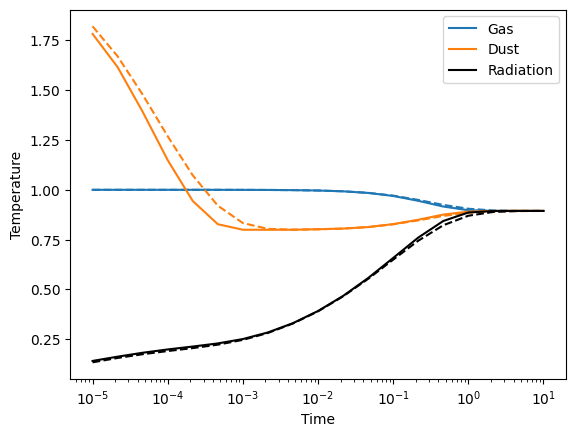

In [3]:
solver = DustyFLD(0.01, 3, 30, a_rad=5, cg=30)

times  = np.geomspace(1e-5, 10, 19)

sol_exp = solver.solve_explicit(times, 1, 2, 0)[1]
sol_imp = solver.solve_implicit(times, 1, 2, 0)[1]


plt.plot(times, sol_exp[0], label='Gas')
plt.plot(times, sol_imp[0], c='C0', ls='--')

plt.plot(times, sol_exp[1], label='Dust')
plt.plot(times, sol_imp[1], c='C1', ls='--')

plt.plot(times, (sol_exp[2]/solver.a_rad)**0.25, c='k', label='Radiation')
plt.plot(times, (sol_imp[2]/solver.a_rad)**0.25, c='k', ls='--')

plt.xscale('log')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Temperature')

In [4]:
c_l = 1
class DustyFLD:
    """FLD for dust+gas temperatures coupled by radiation (no collisions)"""

    def __init__(self, cd, kd, cg=1, kg=1, a_rad=1, fd=None, fg=0, fE=0):
        self.cd = cd 
        self.cg = cg

        self.kd = kd 
        self.kg = kg 

        self.fg = fg
        self.fE = fE
        if fd is None: 
            self.fd = np.zeros_like(self.cd)
        else:
            self.fd = fd

        self.a_rad = a_rad

    def ode(self, Tg, Td, Erad):
        dTg_dt = (self.fg + self.kg*c_l*(Erad - self.a_rad*Tg**4)) / self.cg
        dTd_dt = (self.fd + self.kd*c_l*(Erad - self.a_rad*Td**4)) / self.cd 
        dEr_dt =  self.fE - self.kg*c_l*(Erad - self.a_rad*Tg**4) - np.sum(self.kd*c_l*(Erad - self.a_rad*Td**4))

        return [dTg_dt, dTd_dt, dEr_dt]

    def implicit_step(self, dt, Tg, Td, Erad):
        lg = self.a_rad*self.kg*c_l*Tg**3
        ld = self.a_rad*self.kd*c_l*Td**3   
        
        Zd = (self.cd + 4*ld*dt)
        Zg = (self.cg + 4*lg*dt)

        RHS = Erad + self.fE + np.sum(ld*dt*(self.cd*Td + 4*self.fd*dt)/Zd) + lg*dt*(self.cg*Tg + 4*self.fg*dt)/Zg
 
        NORM = 1 + c_l*dt*(np.sum(self.kd*self.cd/Zd) + self.kg*self.cg/Zg)
        Erad_new = RHS / NORM 

        Tg_new = (self.cg*Tg + self.fg*dt + 3*lg*Tg*dt + self.kg*c_l*dt*Erad_new)/Zg
        Td_new = (self.cd*Td + self.fd*dt + 3*ld*Td*dt + self.kd*c_l*dt*Erad_new)/Zd

        return Tg_new, Td_new, Erad_new

    def solve_implicit(self, times, Tg, Td, Erad):
        y = np.concatenate([[Tg], np.atleast_1d(Td), [Erad]])

        t = 0 
        res = []
        for ti in times:
            dt = ti-t 
            Tg, Td, Erad = self.implicit_step(dt, Tg, Td, Erad)
            res.append(np.concatenate([[Tg], np.atleast_1d(Td), [Erad]]))
            t = ti

        return times, np.array(res).T

    def solve_explicit(self, times, Tg, Td, Erad):

        x = np.concatenate([[Tg], np.atleast_1d(Td), [Erad]])
        
        def f(t, x):
            Tg = x[0]
            Td = x[1:-1]
            Erad = x[-1]

            dTg_dt, dTd_dt, dEr_dt = self.ode(Tg, Td, Erad)

            return np.concatenate([[dTg_dt], np.atleast_1d(dTd_dt), [dEr_dt]])

        sol = solve_ivp(f, [0, times.max()], x, t_eval=times)

        return sol.t, sol.y



Text(0, 0.5, 'Temperature')

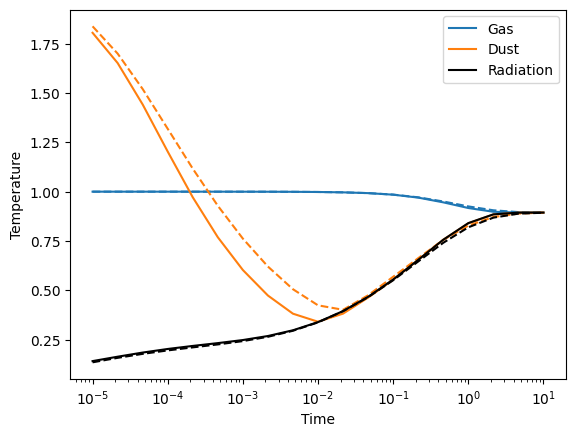

In [5]:
solver = DustyFLD(0.01, 3, a_rad=5, cg=30)

times  = np.geomspace(1e-5, 10, 19)

sol_exp = solver.solve_explicit(times, 1, 2, 0)[1]
sol_imp = solver.solve_implicit(times, 1, 2, 0)[1]


plt.plot(times, sol_exp[0], label='Gas')
plt.plot(times, sol_imp[0], c='C0', ls='--')

plt.plot(times, sol_exp[1], label='Dust')
plt.plot(times, sol_imp[1], c='C1', ls='--')

plt.plot(times, (sol_exp[2]/solver.a_rad)**0.25, c='k', label='Radiation')
plt.plot(times, (sol_imp[2]/solver.a_rad)**0.25, c='k', ls='--')

plt.xscale('log')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Temperature')


In [6]:
c_l = 1
class DustyFLD:
    """FLD for dust+gas with temperatures fully coupled"""

    def __init__(self, cd, kd, cg=1, kg=1, a_rad=1, fd=None, fg=0, fE=0):
        self.cd = cd 
        self.cg = cg

        self.kd = kd 
        self.kg = kg 

        self.fg = fg
        self.fE = fE
        if fd is None: 
            self.fd = np.zeros_like(self.cd)
        else:
            self.fd = fd

        self.a_rad = a_rad

    def ode(self, Tg, Erad):
        k = self.kg + np.sum(self.kd)
        c = self.cg + np.sum(self.cd)

        fg = self.fg + np.sum(self.fd)

        dTg_dt = (     fg + k*c_l*(Erad - self.a_rad*Tg**4)) / c
        dEr_dt =  self.fE - k*c_l*(Erad - self.a_rad*Tg**4)

        return [dTg_dt, dEr_dt]

    def implicit_step(self, dt, Tg, Erad):
        k = self.kg + np.sum(self.kd)
        c = self.cg + np.sum(self.cd)

        l  = self.a_rad*k*c_l*Tg**3

        Z = (c + 4*l*dt)
        fg = self.fg + np.sum(self.fd)

        RHS = Erad + self.fE + l*dt*(c*Tg + 4*fg*dt)/Z
 
        NORM = 1 + c_l*dt*(k*c/Z)
        Erad_new = RHS / NORM 

        Tg_new = (c*Tg + fg*dt + 3*l*Tg*dt + k*c_l*dt*Erad_new)/Z

        return Tg_new, Erad_new

    def solve_implicit(self, times, Tg, Erad):
        y = np.concatenate([[Tg], [Erad]])

        t = 0 
        res = []
        for ti in times:
            dt = ti-t 
            Tg, Erad = self.implicit_step(dt, Tg, Erad)
            res.append(np.concatenate([[Tg], [Erad]]))
            t = ti

        return times, np.array(res).T

    def solve_explicit(self, times, Tg,  Erad):

        x = np.concatenate([[Tg], [Erad]])
        
        def f(t, x):
            Tg = x[0]
            Td = x[1:-1]
            Erad = x[-1]

            dTg_dt, dEr_dt = self.ode(Tg,  Erad)

            return np.concatenate([[dTg_dt], [dEr_dt]])

        sol = solve_ivp(f, [0, times.max()], x, t_eval=times)

        return sol.t, sol.y



Text(0, 0.5, 'Temperature')

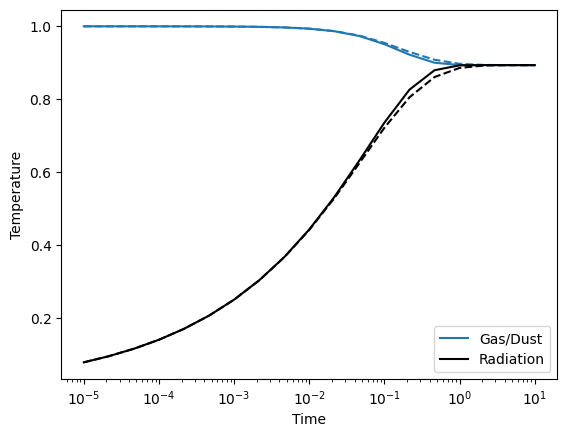

In [7]:
solver = DustyFLD(0.01, 3, a_rad=5, cg=30)

times  = np.geomspace(1e-5, 10, 19)

sol_exp = solver.solve_explicit(times, 1, 0)[1]
sol_imp = solver.solve_implicit(times, 1, 0)[1]


plt.plot(times, sol_exp[0], label='Gas/Dust')
plt.plot(times, sol_imp[0], c='C0', ls='--')

plt.plot(times, (sol_exp[1]/solver.a_rad)**0.25, c='k', label='Radiation')
plt.plot(times, (sol_imp[1]/solver.a_rad)**0.25, c='k', ls='--')

plt.xscale('log')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Temperature')
